In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic Stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin','Name','Ticket','PassengerId'], inplace=True)
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

print("Cleaned! Remaining nulls:\n", df.isnull().sum())

Cleaned! Remaining nulls:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_2233/3086108631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_2233/3086108631.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

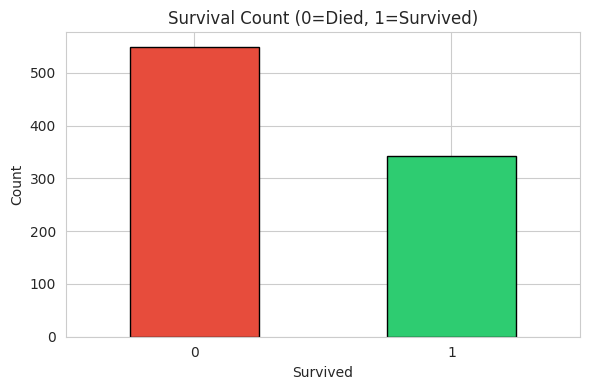

In [6]:
plt.figure(figsize=(6,4))
df['Survived'].value_counts().plot(
    kind='bar', color=['#E74C3C','#2ECC71'], edgecolor='black')
plt.title("Survival Count (0=Died, 1=Survived)")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

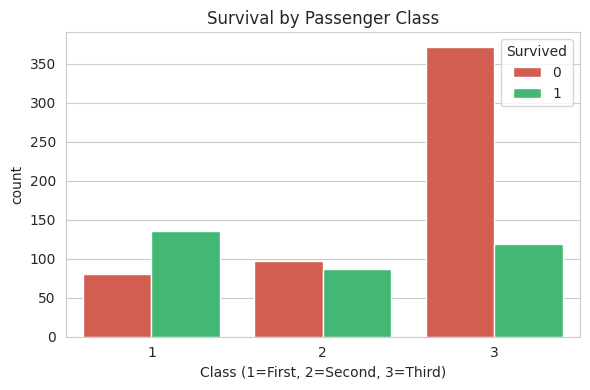

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived',
    palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title("Survival by Passenger Class")
plt.xlabel("Class (1=First, 2=Second, 3=Third)")
plt.tight_layout()
plt.show()

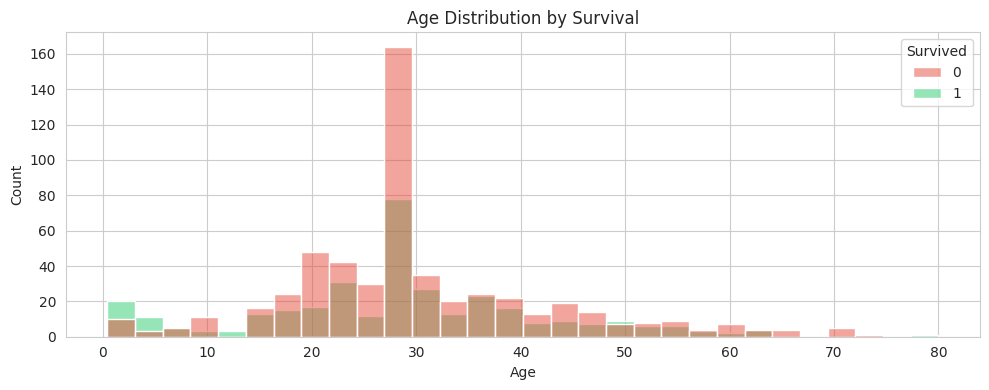

In [8]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Age', hue='Survived',
    bins=30, palette={0:'#E74C3C', 1:'#2ECC71'})
plt.title("Age Distribution by Survival")
plt.tight_layout()
plt.show()

In [9]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Models trained!")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")

Models trained!
Logistic Regression Accuracy: 79.89%
Random Forest Accuracy: 82.68%


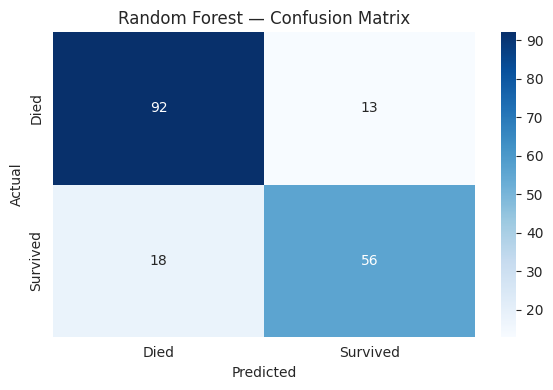

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Died','Survived'],
    yticklabels=['Died','Survived'])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

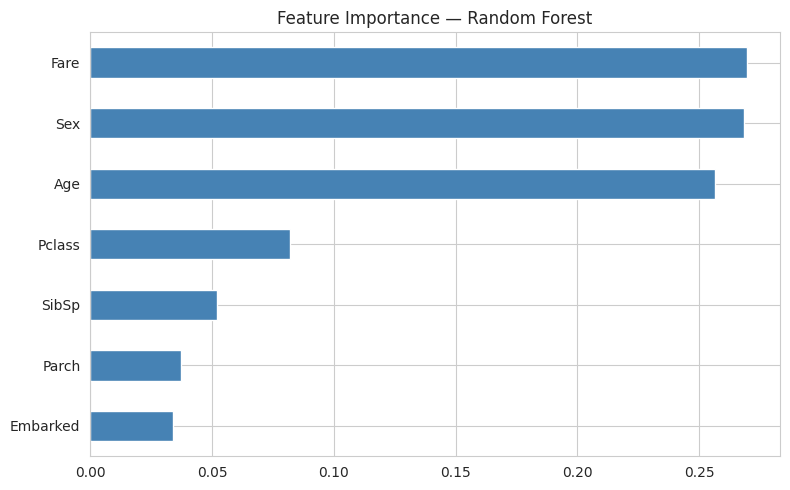

In [11]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

## Titanic Survival Prediction — Key Findings

- Females had significantly higher survival rate than males
- First class passengers survived more than second and third class
- Age played a role — children had higher survival chances
- Random Forest outperformed Logistic Regression
- Most important features: Sex, Fare, Age, Pclass

In [12]:
print("=" * 40)
print("Titanic Survival Prediction Complete!")
print("=" * 40)
print(f"Logistic Regression: {accuracy_score(y_test, lr_pred)*100:.2f}% accuracy")
print(f"Random Forest:       {accuracy_score(y_test, rf_pred)*100:.2f}% accuracy")
print(f"Best Model: Random Forest")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Titanic Survival Prediction Complete!
Logistic Regression: 79.89% accuracy
Random Forest:       82.68% accuracy
Best Model: Random Forest
Training samples: 712
Testing samples:  179
